In [17]:
using JLD2
using Statistics
using DataFrames
using Plots

# =========================================================
# CONFIG
# =========================================================
# Each setting should have:
#   1. EB result files: LIMMA / SD NP / MAD NP / MAD Param
#   2. non-EB result files: t-test / MAD test
#
# If one setting is split across different n values, list both files.
# Example: "method_pvalues(7).jld2" and "method_pvalues(7.01).jld2"

settings = Dict(
    "eps = 0.05" => (
        eb_files = [
            "method_pvalues(2).jld2",
            "method_pvalues(2.1).jld2"
        ],
        nonEB_files = [
            "nonEB_laplace_mixture_eps0p05.jld2"
        ]
    ),

    "eps = 0.10" => (
        eb_files = [
            "method_pvalues(7.1).jld2",
        ],
        nonEB_files = [
            "nonEB_laplace_mixture_eps0p1.jld2"
        ]
    ),

    "eps = 0.15" => (
        eb_files = [
            "method_pvalues(7.2).jld2"
        ],
        nonEB_files = [
            "nonEB_laplace_mixture_eps0p15.jld2"
        ]
    )
)

# Choose :all or :main4
# :all   = t-test, MAD test, LIMMA, SD NP, MAD NP, MAD Param
# :main4 = t-test, MAD test, LIMMA, MAD Param
method_version = :main4


# =========================================================
# Helper functions: combine summaries and p-value stores
# =========================================================

function combine_summary_dicts(summary_list)

    out = Dict(
        "n" => Int[],
        "TP" => Float64[],
        "FP" => Float64[],
        "Power" => Float64[],
        "FDR" => Float64[]
    )

    for s in summary_list
        append!(out["n"], s["n"])
        append!(out["TP"], s["TP"])
        append!(out["FP"], s["FP"])
        append!(out["Power"], s["Power"])
        append!(out["FDR"], s["FDR"])
    end

    ord = sortperm(out["n"])

    for key in keys(out)
        out[key] = out[key][ord]
    end

    return out
end


function combine_pval_stores(store_list)

    out = Dict{Tuple{Int,Int}, Vector{Float64}}()

    for store in store_list
        for (key, val) in store
            out[key] = copy(val)
        end
    end

    return out
end


function combine_is_DE_stores(store_list)

    out = Dict{Tuple{Int,Int}, Vector{Bool}}()

    for store in store_list
        for (key, val) in store
            out[key] = copy(val)
        end
    end

    return out
end

combine_is_DE_stores (generic function with 1 method)

In [18]:


# =========================================================
# Ranking metrics
# =========================================================

function hits_at_k(pvals, is_DE; k=100)

    k_use =
        min(k, length(pvals))

    top_idx =
        partialsortperm(
            pvals,
            1:k_use
        )

    return sum(is_DE[top_idx])
end


function average_precision(pvals, is_DE)

    ord =
        sortperm(pvals)

    truth_ranked =
        is_DE[ord]

    n_de =
        sum(truth_ranked)

    if n_de == 0
        return NaN
    end

    cum_tp =
        cumsum(truth_ranked)

    precision_at_k =
        cum_tp ./ collect(1:length(pvals))

    ap =
        sum(precision_at_k[truth_ranked]) / n_de

    return ap
end


function build_ranking_summary(methods, is_DE_store; k=100)

    common_keys =
        reduce(
            intersect,
            [Set(keys(store)) for store in values(methods)]
        )

    common_keys =
        intersect(
            common_keys,
            Set(keys(is_DE_store))
        )

    println("Number of common (n, rep) pairs = ", length(common_keys))

    ranking_df = DataFrame(
        n = Int[],
        rep = Int[],
        method = String[],
        hits100 = Int[],
        AP = Float64[]
    )

    for key in sort(collect(common_keys))

        n, r =
            key

        is_DE =
            is_DE_store[key]

        for (method, store) in methods

            pvals =
                store[key]

            push!(
                ranking_df,
                (
                    n = n,
                    rep = r,
                    method = method,
                    hits100 = hits_at_k(pvals, is_DE; k=k),
                    AP = average_precision(pvals, is_DE)
                )
            )
        end
    end

    ranking_summary =
        DataFrames.combine(
            DataFrames.groupby(ranking_df, [:n, :method]),

            :hits100 => mean => :mean_hits100,
            :hits100 => std  => :sd_hits100,

            :AP => mean => :mean_AP,
            :AP => std  => :sd_AP,

            DataFrames.nrow => :R
        )

    ranking_summary.se_hits100 =
        ranking_summary.sd_hits100 ./ sqrt.(ranking_summary.R)

    ranking_summary.se_AP =
        ranking_summary.sd_AP ./ sqrt.(ranking_summary.R)

    sort!(ranking_summary, [:method, :n])

    return ranking_df, ranking_summary
end


build_ranking_summary (generic function with 1 method)


Plotting setting: eps = 0.05
Number of common (n, rep) pairs = 800

Full summary table for eps = 0.05:
32×6 DataFrame
 Row │ n      method       Power      FDR         mean_hits100  mean_AP  
     │ Int64  String       Float64    Float64     Float64?      Float64? 
─────┼───────────────────────────────────────────────────────────────────
   1 │     4  LIMMA        0.0423995  0.00106443         79.24  0.861575
   2 │     5  LIMMA        0.196907   0.00276917         79.12  0.857114
   3 │     6  LIMMA        0.294326   0.00372265         78.3   0.856051
   4 │     8  LIMMA        0.389801   0.00751376         76.63  0.835357
   5 │    10  LIMMA        0.42665    0.00611181         76.43  0.830955
   6 │    20  LIMMA        0.40761    0.011606           72.59  0.789698
   7 │    30  LIMMA        0.354596   0.0100139          68.17  0.752293
   8 │    40  LIMMA        0.317337   0.00840449         66.75  0.731585
   9 │     4  MAD (Param)  0.0400545  0.00176786         79.56  0.864105
  

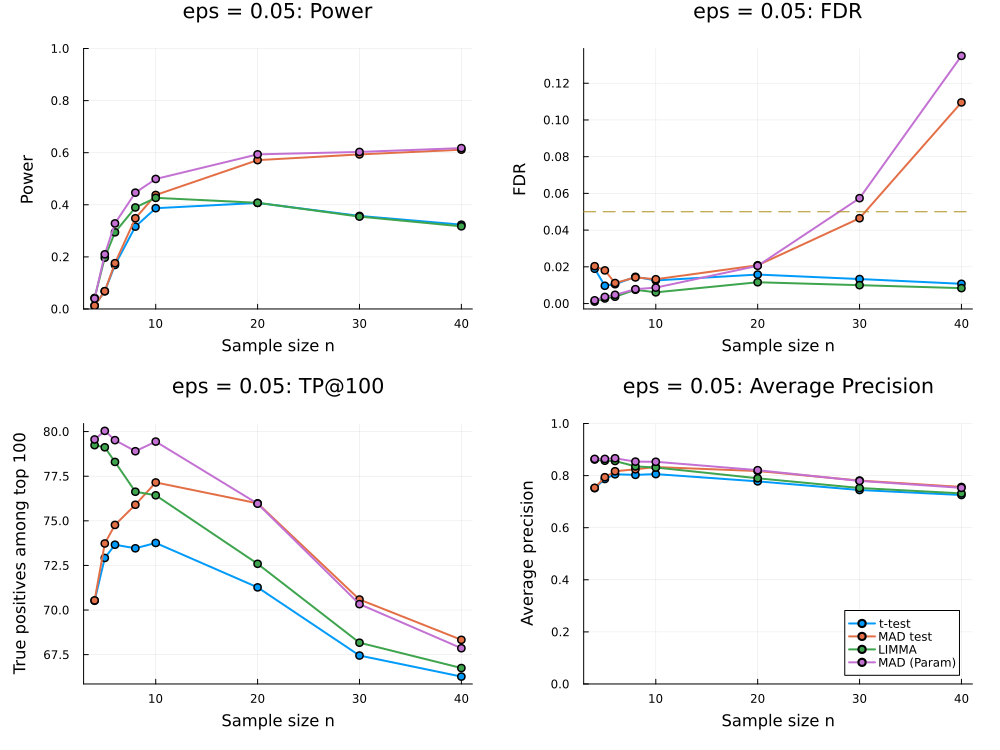


Plotting setting: eps = 0.15
Number of common (n, rep) pairs = 800

Full summary table for eps = 0.15:
32×6 DataFrame
 Row │ n      method       Power        FDR         mean_hits100  mean_AP  
     │ Int64  String       Float64      Float64     Float64?      Float64? 
─────┼─────────────────────────────────────────────────────────────────────
   1 │     4  LIMMA        0.000604446  0.0                68.73  0.745378
   2 │     5  LIMMA        0.00470116   0.0                67.09  0.722671
   3 │     6  LIMMA        0.0198494    0.0                64.9   0.7023
   4 │     8  LIMMA        0.0465826    0.0                61.3   0.66557
   5 │    10  LIMMA        0.0650125    0.0                59.32  0.63954
   6 │    20  LIMMA        0.0471798    0.0                49.74  0.534543
   7 │    30  LIMMA        0.0208269    0.00166667         43.08  0.45898
   8 │    40  LIMMA        0.0150724    0.00666667         40.29  0.420162
   9 │     4  MAD (Param)  0.000604446  0.0               

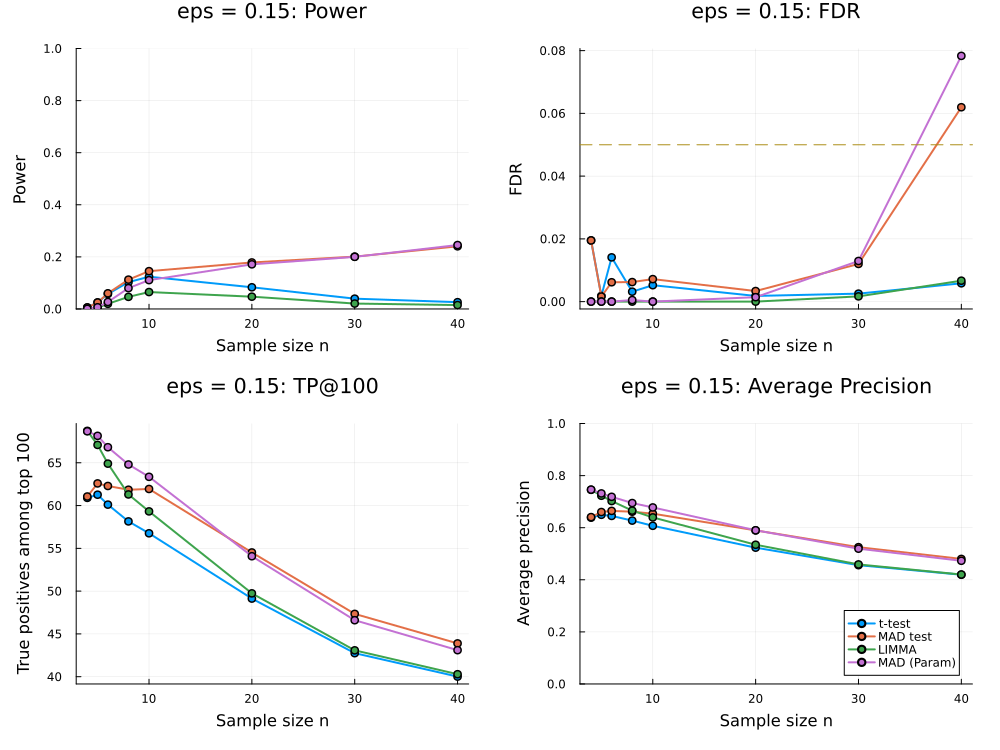


Plotting setting: eps = 0.10
Number of common (n, rep) pairs = 800

Full summary table for eps = 0.10:
32×6 DataFrame
 Row │ n      method       Power       FDR         mean_hits100  mean_AP  
     │ Int64  String       Float64     Float64     Float64?      Float64? 
─────┼────────────────────────────────────────────────────────────────────
   1 │     4  LIMMA        0.00357683  0.0                73.73  0.802447
   2 │     5  LIMMA        0.0434022   0.0                72.73  0.786828
   3 │     6  LIMMA        0.102182    0.001              71.14  0.776055
   4 │     8  LIMMA        0.173602    0.00285579         68.61  0.744848
   5 │    10  LIMMA        0.207438    0.00037037         67.43  0.73009
   6 │    20  LIMMA        0.159212    0.00208333         60.01  0.648563
   7 │    30  LIMMA        0.100959    0.00318056         54.08  0.589569
   8 │    40  LIMMA        0.0745129   0.00391667         51.01  0.551938
   9 │     4  MAD (Param)  0.00367844  0.0                73.88  

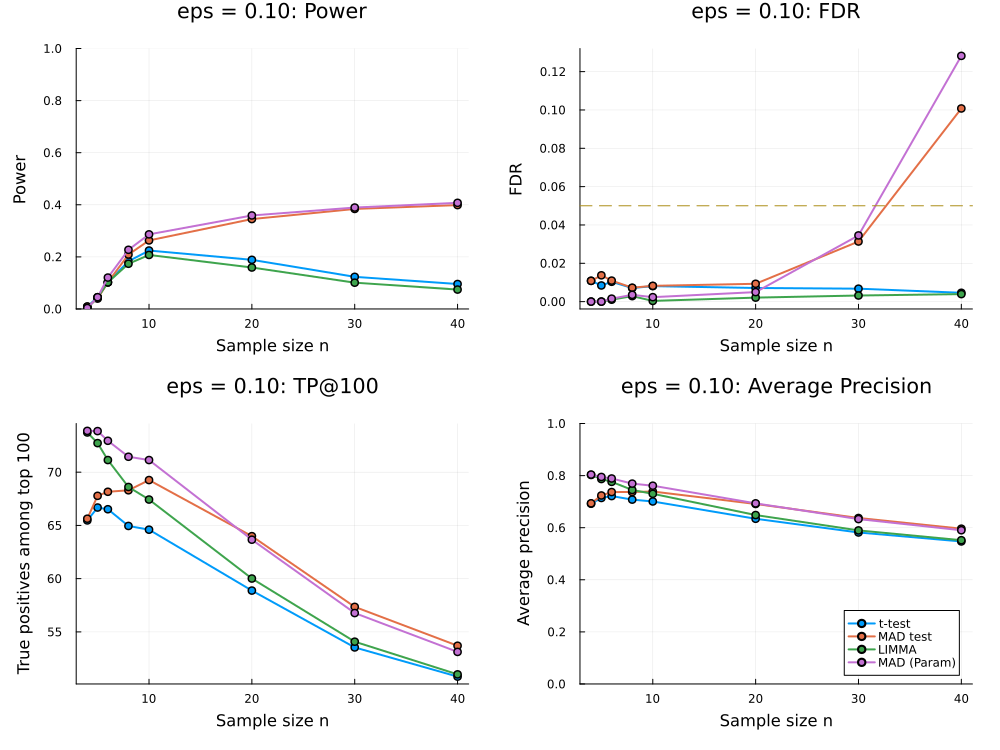

In [19]:


# =========================================================
# Performance dataframe
# =========================================================

function summary_to_df(summary, method)

    return DataFrame(
        n = summary["n"],
        method = fill(method, length(summary["n"])),
        Power = summary["Power"],
        FDR = summary["FDR"]
    )
end


function build_performance_df(performance_summaries, method_order)

    dfs = [
        summary_to_df(performance_summaries[method], method)
        for method in method_order
    ]

    performance_df =
        vcat(dfs...)

    sort!(performance_df, [:method, :n])

    return performance_df
end


# =========================================================
# Load one setting
# =========================================================

function load_setting(eb_files, nonEB_files; method_version=:all)

    eb_list =
        [JLD2.load(f) for f in eb_files]

    nonEB_list =
        [JLD2.load(f) for f in nonEB_files]

    # -----------------------------
    # EB summaries
    # -----------------------------

    limma_summary =
        combine_summary_dicts(
            [d["limma_summary"] for d in eb_list]
        )

    epb_summary =
        combine_summary_dicts(
            [d["epb_summary"] for d in eb_list]
        )

    mad_summary =
        combine_summary_dicts(
            [d["mad_summary"] for d in eb_list]
        )

    mad_param_gl_summary =
        combine_summary_dicts(
            [d["mad_param_gl_summary"] for d in eb_list]
        )

    # -----------------------------
    # EB p-values
    # -----------------------------

    limma_pvals_store =
        combine_pval_stores(
            [d["limma_pvals_store"] for d in eb_list]
        )

    epb_pvals_store =
        combine_pval_stores(
            [d["epb_pvals_store"] for d in eb_list]
        )

    mad_pvals_store =
        combine_pval_stores(
            [d["mad_pvals_store"] for d in eb_list]
        )

    mad_param_pvals_store =
        combine_pval_stores(
            [d["mad_param_pvals_store"] for d in eb_list]
        )

    # -----------------------------
    # Truth labels
    # -----------------------------

    is_DE_store =
        combine_is_DE_stores(
            [d["is_DE_store"] for d in eb_list]
        )

    # -----------------------------
    # Non-EB summaries
    # -----------------------------

    ttest_summary =
        combine_summary_dicts(
            [d["ttest_summary"] for d in nonEB_list]
        )

    mad_test_summary =
        combine_summary_dicts(
            [d["mad_test_summary"] for d in nonEB_list]
        )

    # -----------------------------
    # Non-EB p-values
    # -----------------------------

    ttest_pvals_store =
        combine_pval_stores(
            [d["ttest_pvals_store"] for d in nonEB_list]
        )

    mad_test_pvals_store =
        combine_pval_stores(
            [d["mad_test_pvals_store"] for d in nonEB_list]
        )

    # -----------------------------
    # Choose methods
    # -----------------------------

    if method_version == :main4

        method_order = [
            "t-test",
            "MAD test",
            "LIMMA",
            "MAD (Param)"
        ]

        methods = Dict(
            "t-test"      => ttest_pvals_store,
            "MAD test"    => mad_test_pvals_store,
            "LIMMA"       => limma_pvals_store,
            "MAD (Param)" => mad_param_pvals_store
        )

        performance_summaries = Dict(
            "t-test"      => ttest_summary,
            "MAD test"    => mad_test_summary,
            "LIMMA"       => limma_summary,
            "MAD (Param)" => mad_param_gl_summary
        )

    else

        method_order = [
            "t-test",
            "MAD test",
            "LIMMA",
            "SD (NP)",
            "MAD (NP)",
            "MAD (Param)"
        ]

        methods = Dict(
            "t-test"      => ttest_pvals_store,
            "MAD test"    => mad_test_pvals_store,
            "LIMMA"       => limma_pvals_store,
            "SD (NP)"     => epb_pvals_store,
            "MAD (NP)"    => mad_pvals_store,
            "MAD (Param)" => mad_param_pvals_store
        )

        performance_summaries = Dict(
            "t-test"      => ttest_summary,
            "MAD test"    => mad_test_summary,
            "LIMMA"       => limma_summary,
            "SD (NP)"     => epb_summary,
            "MAD (NP)"    => mad_summary,
            "MAD (Param)" => mad_param_gl_summary
        )
    end

    return method_order, methods, performance_summaries, is_DE_store
end


# =========================================================
# Plotting functions
# =========================================================

function plot_metric(
    df,
    method_order,
    ycol;
    ylabel = "",
    title = "",
    legend = false,
    ylim = nothing,
    hline_value = nothing
)

    p = plot(
        xlabel = "Sample size n",
        ylabel = ylabel,
        title = title,
        legend = legend
    )

    if ylim !== nothing
        plot!(
            p,
            ylim = ylim
        )
    end

    for method in method_order

        tmp =
            filter(
                row -> row.method == method,
                df
            )

        sort!(tmp, :n)

        plot!(
            p,
            tmp.n,
            tmp[!, ycol],
            marker = :circle,
            linewidth = 2,
            label = method
        )
    end

    if hline_value !== nothing
        hline!(
            p,
            [hline_value],
            linestyle = :dash,
            label = ""
        )
    end

    return p
end


function plot_all_metrics(plot_df, method_order; title_prefix="")

    p_power =
        plot_metric(
            plot_df,
            method_order,
            :Power;
            ylabel = "Power",
            title = "$(title_prefix)Power",
            ylim = (0, 1)
        )

    p_fdr =
        plot_metric(
            plot_df,
            method_order,
            :FDR;
            ylabel = "FDR",
            title = "$(title_prefix)FDR",
            hline_value = 0.05
        )

    p_hits =
        plot_metric(
            plot_df,
            method_order,
            :mean_hits100;
            ylabel = "True positives among top 100",
            title = "$(title_prefix)TP@100"
        )

    p_ap =
        plot_metric(
            plot_df,
            method_order,
            :mean_AP;
            ylabel = "Average precision",
            title = "$(title_prefix)Average Precision",
            ylim = (0, 1),
            legend = :bottomright
        )

    p_all =
        plot(
            p_power,
            p_fdr,
            p_hits,
            p_ap,
            layout = (2, 2),
            size = (1000, 750),
            margin = 5Plots.mm
        )

    return p_all
end


# =========================================================
# Main loop: make one figure per epsilon setting
# =========================================================

for (setting_name, files) in settings

    println("\n============================================")
    println("Plotting setting: $setting_name")
    println("============================================")

    method_order, methods, performance_summaries, is_DE_store =
        load_setting(
            files.eb_files,
            files.nonEB_files;
            method_version = method_version
        )

    ranking_df, ranking_summary =
        build_ranking_summary(
            methods,
            is_DE_store;
            k = 100
        )

    performance_df =
        build_performance_df(
            performance_summaries,
            method_order
        )


    plot_df =
        DataFrames.leftjoin(
            performance_df,
            ranking_summary[:, [:n, :method, :mean_hits100, :mean_AP]],
            on = [:n, :method]
        )

    sort!(plot_df, [:method, :n])
    println("\nFull summary table for $setting_name:")
    show(
        stdout,
        MIME("text/plain"),
        plot_df;
        allrows = true,
        allcols = true
    )
    println("\n")

    # display(plot_df)

    p =
        plot_all_metrics(
            plot_df,
            method_order;
            title_prefix = "$setting_name: "
        )

    display(p)

    # # Save figure
    # clean_name =
    #     replace(setting_name, " " => "_", "=" => "", "." => "p")

    # savefig(
    #     p,
    #     "ranking_power_fdr_$(clean_name).pdf"
    # )

    # savefig(
    #     p,
    #     "ranking_power_fdr_$(clean_name).png"
    # )
end